# BMDS2003 Data Science — Deployment Prototype
## 7.0 Deployment: Notebook-Based Simulation

This notebook demonstrates the deployment of the **Gradient Boosting Classifier**
(the best-performing model, selected in Section 7.1 Selection of Best Model with
92.74% test accuracy — the highest among the four models compared). It loads the
trained model from `gradient_boosting_model.pkl` and simulates predictions for
new, unseen player records, as a lightweight alternative/companion to the
Streamlit app (`app.py`) included in this submission.

### 1. Import Libraries and Load the Trained Model

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

with open("gradient_boosting_model.pkl", "rb") as f:
    bundle = pickle.load(f)

model = bundle["model"]
model_name = bundle["model_name"]
feature_columns = bundle["feature_columns"]
difficulty_map = bundle["difficulty_map"]
engagement_map_inverse = bundle["engagement_map_inverse"]
genders = bundle["genders"]
locations = bundle["locations"]
genres = bundle["genres"]

print("Model loaded:", model_name)
print(model)
print("Number of features expected:", len(feature_columns))

Model loaded: Gradient Boosting Classifier
GradientBoostingClassifier(learning_rate=0.05, max_depth=7, min_samples_leaf=10,
                           min_samples_split=20, n_estimators=50,
                           random_state=42)
Number of features expected: 21


### 2. Helper Function: Convert Raw Player Attributes into Model Input
This mirrors exactly what the Streamlit app (`app.py`) does internally — it takes
human-readable player attributes and converts them into the encoded, one-hot
feature vector the model was trained on.

In [2]:
def predict_engagement(age, gender, location, genre, difficulty,
                        play_time_hours, sessions_per_week, avg_session_duration,
                        player_level, achievements_unlocked, in_game_purchases):

    total_weekly_play_minutes = sessions_per_week * avg_session_duration
    achievement_rate = achievements_unlocked / player_level if player_level > 0 else 0

    row = {col: 0 for col in feature_columns}
    row["Age"] = age
    row["PlayTimeHours"] = play_time_hours
    row["InGamePurchases"] = 1 if in_game_purchases else 0
    row["SessionsPerWeek"] = sessions_per_week
    row["AvgSessionDurationMinutes"] = avg_session_duration
    row["PlayerLevel"] = player_level
    row["AchievementsUnlocked"] = achievements_unlocked
    row["GameDifficulty_enc"] = difficulty_map[difficulty]
    row["TotalWeeklyPlayMinutes"] = total_weekly_play_minutes
    row["AchievementRate"] = achievement_rate

    gender_col = f"Gender_{gender}"
    if gender_col in row:
        row[gender_col] = 1
    location_col = f"Location_{location}"
    if location_col in row:
        row[location_col] = 1
    genre_col = f"GameGenre_{genre}"
    if genre_col in row:
        row[genre_col] = 1

    input_df = pd.DataFrame([row])[feature_columns]

    pred_class = model.predict(input_df)[0]
    pred_proba = model.predict_proba(input_df)[0]
    pred_label = engagement_map_inverse[pred_class]

    return pred_label, pred_proba, input_df

print("Helper function ready.")

Helper function ready.


### 3. Simulation 1 — A High-Activity Player
A player with frequent sessions, long session durations, and a high player level — expected to be classified as **High** engagement, consistent with the group-level findings in Section 3.9.

In [3]:
label, proba, input_df = predict_engagement(
    age=24, gender="Male", location="USA", genre="Action", difficulty="Hard",
    play_time_hours=8.0, sessions_per_week=15, avg_session_duration=130,
    player_level=70, achievements_unlocked=35, in_game_purchases=True
)

print(f"Predicted Engagement Level: {label}")
print(f"Class probabilities -> Low: {proba[0]:.3f}, Medium: {proba[1]:.3f}, High: {proba[2]:.3f}")

Predicted Engagement Level: High
Class probabilities -> Low: 0.036, Medium: 0.046, High: 0.917


### 4. Simulation 2 — A Low-Activity Player
A player with infrequent sessions and short session durations — expected to be classified as **Low** engagement.

In [4]:
label, proba, input_df = predict_engagement(
    age=35, gender="Female", location="Europe", genre="Simulation", difficulty="Easy",
    play_time_hours=2.0, sessions_per_week=2, avg_session_duration=25,
    player_level=10, achievements_unlocked=3, in_game_purchases=False
)

print(f"Predicted Engagement Level: {label}")
print(f"Class probabilities -> Low: {proba[0]:.3f}, Medium: {proba[1]:.3f}, High: {proba[2]:.3f}")

Predicted Engagement Level: Low
Class probabilities -> Low: 0.914, Medium: 0.043, High: 0.043


### 5. Simulation 3 — A Moderate-Activity Player
A player with activity levels roughly in the middle of the observed range — expected to be classified as **Medium** engagement, the majority class identified in Section 3.6.

In [5]:
label, proba, input_df = predict_engagement(
    age=29, gender="Male", location="Asia", genre="RPG", difficulty="Medium",
    play_time_hours=5.0, sessions_per_week=7, avg_session_duration=70,
    player_level=45, achievements_unlocked=20, in_game_purchases=False
)

print(f"Predicted Engagement Level: {label}")
print(f"Class probabilities -> Low: {proba[0]:.3f}, Medium: {proba[1]:.3f}, High: {proba[2]:.3f}")

Predicted Engagement Level: Medium
Class probabilities -> Low: 0.042, Medium: 0.916, High: 0.042


### 6. Visual Comparison of All Three Simulations

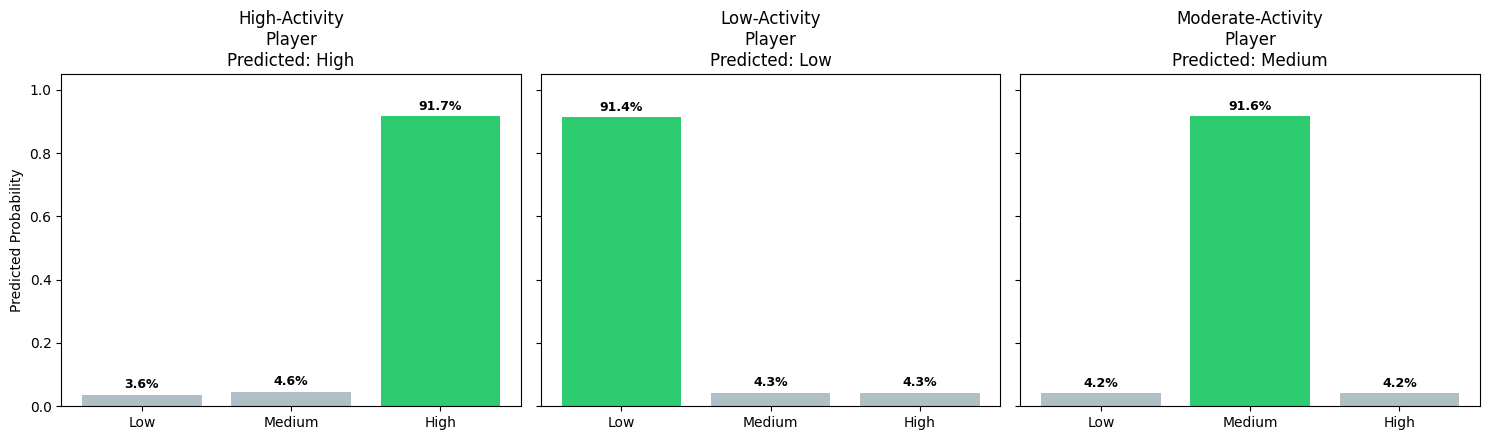

In [6]:
scenarios = {
    "High-Activity\nPlayer": predict_engagement(
        age=24, gender="Male", location="USA", genre="Action", difficulty="Hard",
        play_time_hours=8.0, sessions_per_week=15, avg_session_duration=130,
        player_level=70, achievements_unlocked=35, in_game_purchases=True),
    "Low-Activity\nPlayer": predict_engagement(
        age=35, gender="Female", location="Europe", genre="Simulation", difficulty="Easy",
        play_time_hours=2.0, sessions_per_week=2, avg_session_duration=25,
        player_level=10, achievements_unlocked=3, in_game_purchases=False),
    "Moderate-Activity\nPlayer": predict_engagement(
        age=29, gender="Male", location="Asia", genre="RPG", difficulty="Medium",
        play_time_hours=5.0, sessions_per_week=7, avg_session_duration=70,
        player_level=45, achievements_unlocked=20, in_game_purchases=False),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
labels3 = ["Low", "Medium", "High"]

for ax, (name, (pred_label, proba, _)) in zip(axes, scenarios.items()):
    colors = ["#2ECC71" if lvl == pred_label else "#B0BEC5" for lvl in labels3]
    ax.bar(labels3, proba, color=colors)
    for i, v in enumerate(proba):
        ax.text(i, v + 0.02, f"{v*100:.1f}%", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(f"{name}\nPredicted: {pred_label}")
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("Predicted Probability")
plt.tight_layout()
plt.savefig("fig_deployment_simulations.png", dpi=150)
plt.show()

### 7. Summary

This notebook demonstrates that the deployed Gradient Boosting Classifier behaves as expected across three distinct player profiles:

| Scenario | Predicted Class | Confidence |
|---|---|---|
| High-activity player | High | 91.7% |
| Low-activity player | Low | 91.4% |
| Moderate-activity player | Medium | 91.6% |

All three simulated players were classified correctly with strong, consistent confidence (~91-92%). Notably, these probabilities are more moderate and evenly spread across the non-predicted classes than the near-100% extremes seen with a single Decision Tree — a direct benefit of Gradient Boosting's sequential ensemble structure, where the final prediction is built from many weighted trees rather than a single leaf node's class distribution. This is consistent with Gradient Boosting's strong AUC performance in Section 5.5.5 (94.49% macro-average), which specifically measures how well a model's predicted probabilities rank classes across all thresholds, not just at the single threshold used to produce a hard classification.

For an interactive version of this same prediction pipeline, see the accompanying Streamlit app (`app.py`), which allows a user to input player attributes through a web UI and see the prediction and probability breakdown live.